# **PHẦN 3: KỸ THUẬT ĐẶC TRƯNG**
## **1. Định nghĩa vấn đề**
+ **Mô tả**:
   - Phát hiện và phân loại mã độc trên các thiết bị di động Android bằng tập dữ liệu Android Malware Detection.
   - Dữ liệu ban đầu bao gồm 1 file (Android_Malware.csv)
   - Link tập dữ liệu: https://www.kaggle.com/datasets/subhajournal/android-malware-detection

+ **Mục tiêu**:
   - Chia dữ liệu thành các tập train, validation và test.
   - Trích ra các đặc trưng cần thiết cho việc huấn luyện mô hình.
   - Xử lý dữ liệu để mô hình học được hiệu quả.

## **2. Chuẩn bị vấn đề**

### 2.1. Import các thư viện cần thiết

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
import math
import itertools
import ipaddress

from sklearn.model_selection import train_test_split
RANDOM_STATE = 42

from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 500)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

### 2.2. Lấy tập dữ liệu đã xử lý

In [50]:
dataFrame = pd.read_parquet("../data_processed/cleaned_data.parquet")
dataFrame.head()

,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,10.42.0.211,50004,172.217.6.202,443.00,6.00,13/06/2017 11:52:39,37027,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,54.01,37027.00,0.00,37027.00,37027.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,32,32,27.01,27.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1,0.00,0.00,0.00,32.00,1.00,0.00,1.00,0.00,2994.00,362.00,0.00,32.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Android_Adware
1,10.42.0.211,35455,172.217.6.202,443.00,6.00,13/06/2017 11:52:39,36653,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,54.57,36653.00,0.00,36653.00,36653.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,32,32,27.28,27.28,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1,0.00,0.00,0.00,32.00,1.00,0.00,1.00,0.00,2860.00,362.00,0.00,32.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Android_Adware
2,10.42.0.211,51775,131.253.61.68,443.00,6.00,13/06/2017 11:52:42,534099,8,12,1011.00,11924.00,581.00,0.00,126.38,207.80,1460.00,0.00,993.67,656.47,24218.36,37.45,28110.47,43148.10,158676.00,8.00,481340.00,68762.86,62376.18,158676.00,449.00,487990.00,44362.73,86342.04,217790.00,8.00,0.00,180,244,14.98,22.47,0.00,1460.00,615.95,672.74,452585.55,0.00,0.00,1.00,0.00,0.00,1,646.75,126.38,993.67,180.00,8.00,1011.00,12.00,11924.00,65535.00,63441.00,3.00,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Android_Adware
3,10.42.0.211,51775,131.253.61.68,443.00,6.00,13/06/2017 11:52:43,9309,3,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,322.27,4654.50,5137.13,8287.00,1022.00,9309.00,4654.50,5137.13,8287.00,1022.00,0.00,0.00,0.00,0.00,0.00,0.00,60,0,322.27,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0,0.00,0.00,0.00,60.00,3.00,0.00,0.00,0.00,65535.00,-1.00,0.00,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Android_Adware
4,10.42.0.211,51776,131.253.61.68,443.00,6.00,13/06/2017 11:52:42,19890496,8,6,430.00,5679.00,218.00,0.00,53.75,99.54,1460.00,0.00,946.50,710.41,307.13,0.70,1530038.15,5377887.23,19426714.00,7.00,19890496.00,2841499.43,7314093.15,19426714.00,639.00,410964.00,82192.80,154845.68,355945.00,7.00,0.00,180,124,0.40,0.30,0.00,1460.00,407.27,626.96,393076.92,0.00,0.00,1.00,0.00,0.00,0,436.36,53.75,946.50,180.00,8.00,430.00,6.00,5679.00,65535.00,64022.00,2.00,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Android_Adware


In [51]:
dataFrame.describe()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00,355626.00
mean,39138.30,5198.78,8.34,10929867.00,7.36,10.49,679.20,11294.21,212.00,12.52,59.64,79.53,320.41,23.06,168.54,123.48,83990.02,5494.63,3175840.51,2426832.10,9448629.82,2057904.89,7540020.42,3206521.80,1934146.68,6253338.88,2079854.32,5632490.02,946166.79,1407310.90,4709313.59,342623.64,0.07,-760134.33,-1580875.21,4685.55,814.70,8.41,374.62,115.16,144.90,71484.73,0.02,0.07,0.33,0.43,0.20,0.56,127.43,59.64,168.54,-760134.33,7.36,679.20,10.49,11294.21,23386.88,2032.59,1.52,-28318.50,162814.25,21952.25,185156.39,145653.43,4025723.94,318252.73,4304875.52,3779036.58
std,17866.23,14350.92,4.57,21808704.21,67.01,191.68,19418.64,276388.08,366.94,58.30,119.31,154.23,540.18,59.01,311.33,229.67,911274.88,39135.25,8459910.04,6202485.87,18292007.75,7922457.19,18431955.47,8859205.67,6110724.09,14473815.81,8166515.19,18160175.31,4583240.11,5227302.51,15179322.37,3750298.78,0.25,209046698.67,438567892.58,36259.32,8590.26,21.32,563.92,193.97,224.70,137222.15,0.13,0.25,0.47,0.50,0.40,0.64,199.98,119.31,311.33,209046698.67,67.01,19418.64,191.68,276388.08,30744.98,8532.74,14.94,5543874.68,881776.49,286024.43,1019476.56,842365.89,14415177.99,2882901.08,15140077.13,14070418.50
min,0.00,0.00,0.00,-1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-2000000.00,-1.00,0.00,-1.00,-43.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-75333323990.00,-143691334339.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-75333323990.00,1.00,0.00,0.00,0.00,-1.00,-1.00,0.00,-1395062813.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,34559.00,80.00,6.00,48886.25,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.63,24575.18,0.00,42029.50,40.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,32.00,0.00,0.41,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,32.00,1.00,0.00,0.00,0.00,31.00,-1.00,0.00,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,43226.00,443.00,6.00,560232.00,2.00,1.00,31.00,26.00,31.00,0.00,28.50,0.00,26.00,0.00,15.50,0.00,89.88,7.76,230601.00,0.00,351228.50,3502.00,254433.00,45282.50,0.00,128399.00,93.00,0.00,0.00,0.00,0.00,0.00,0.00,60.00,32.00,3.95,0.88,0.00,45.00,3

## **3. Thực hiện vấn đề**

### 3.1. Chia dữ liệu thành các tập train, validation và test
Dữ liệu được chia làm 3 tập train/validation/test theo tỷ lệ chia 80%/10%/10%.

In [52]:
X = dataFrame.drop(columns="Label")
y = dataFrame["Label"]

x_train, x_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=RANDOM_STATE, 
    stratify=y
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, 
    test_size=0.50, 
    random_state=RANDOM_STATE, 
    stratify=y_temp
)

In [53]:
x_train.describe()

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00
mean,39136.50,5194.19,8.34,10943088.14,7.47,10.70,695.73,11571.29,212.43,12.50,59.79,79.74,321.04,23.08,168.94,123.75,84808.64,5521.34,3179751.26,2423203.94,9452695.16,2064370.91,7552950.25,3212167.21,1931827.86,6258796.68,2086876.62,5648452.01,948144.69,1405644.94,4714245.83,345635.27,0.07,-1019040.60,-2083347.28,4716.93,811.44,8.40,375.43,115.44,145.26,71708.75,0.02,0.07,0.33,0.43,0.20,0.56,127.72,59.79,168.94,-1019040.60,7.47,695.73,10.70,11571.29,23405.27,2027.03,1.55,-30501.38,162595.84,22865.30,185819.85,144703.07,4027437.15,323001.61,4310192.47,3777275.96
std,17860.95,14344.34,4.57,21834634.31,72.44,204.52,21526.06,295015.12,367.34,58.29,119.69,154.53,540.52,59.11,311.74,229.86,943653.32,39481.91,8470237.64,6189795.35,18289972.23,7939295.62,18461121.60,8873834.79,6107650.88,14474153.66,8184211.88,18193956.70,4588826.24,5210473.76,15174387.25,3762164.93,0.25,231172476.84,487682702.88,36579.11,8608.14,21.12,564.37,194.23,224.96,137443.74,0.13,0.25,0.47,0.50,0.40,0.64,200.23,119.69,311.74,231172476.84,72.44,21526.06,204.52,295015.12,30750.41,8520.10,16.33,5619395.31,866421.67,296456.75,1015687.13,823562.52,14409583.23,2912244.97,15144980.26,14059999.18
min,0.00,0.00,0.00,-1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-2000000.00,-1.00,0.00,-1.00,-43.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-75333323990.00,-143691334339.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-75333323990.00,1.00,0.00,0.00,0.00,-1.00,-1.00,0.00,-1395062813.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,34559.00,80.00,6.00,48958.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.63,24619.50,0.00,42220.50,40.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,32.00,0.00,0.41,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,32.00,1.00,0.00,0.00,0.00,31.00,-1.00,0.00,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,43217.00,443.00,6.00,561209.50,2.00,1.00,31.00,26.00,31.00,0.00,28.58,0.00,26.00,0.00,15.50,0.00,90.76,7.76,230506.83,0.00,352018.00,3519.00,255555.00,45515.00,0.00,130086.00,93.00,0.00,0.00,0.00,0.00,0.00,0.00,60.00,32.00,3.95,0.88,0.00,46.00

### 3.2. Map giá trị của biến mục tiêu (Label) thành các giá trị số tương ứng.

In [54]:
mapping = {'Android_Adware': 0,
            'Android_Scareware': 1,
            'Android_SMS_Malware': 2,
            'Benign': 3
          }

y_train = y_train.map(mapping)
y_val = y_val.map(mapping)
y_test = y_test.map(mapping)

y_train.head()

341993    3
300839    2
242949    1
130533    0
287524    2
Name: Label, dtype: int64

### 3.3. Giảm chiều dữ liệu
Các biến có tương quan dương cao (> 0.79) được loại bỏ để giảm chiều dữ liệu.

In [55]:
corr_matrix = x_train.select_dtypes(include=["number"]).corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.79)]

x_train = x_train.drop(columns=to_drop)
x_val = x_val.drop(columns=to_drop)
x_test = x_test.drop(columns=to_drop)

print(x_train.shape[1] == x_val.shape[1] == x_test.shape[1])

True


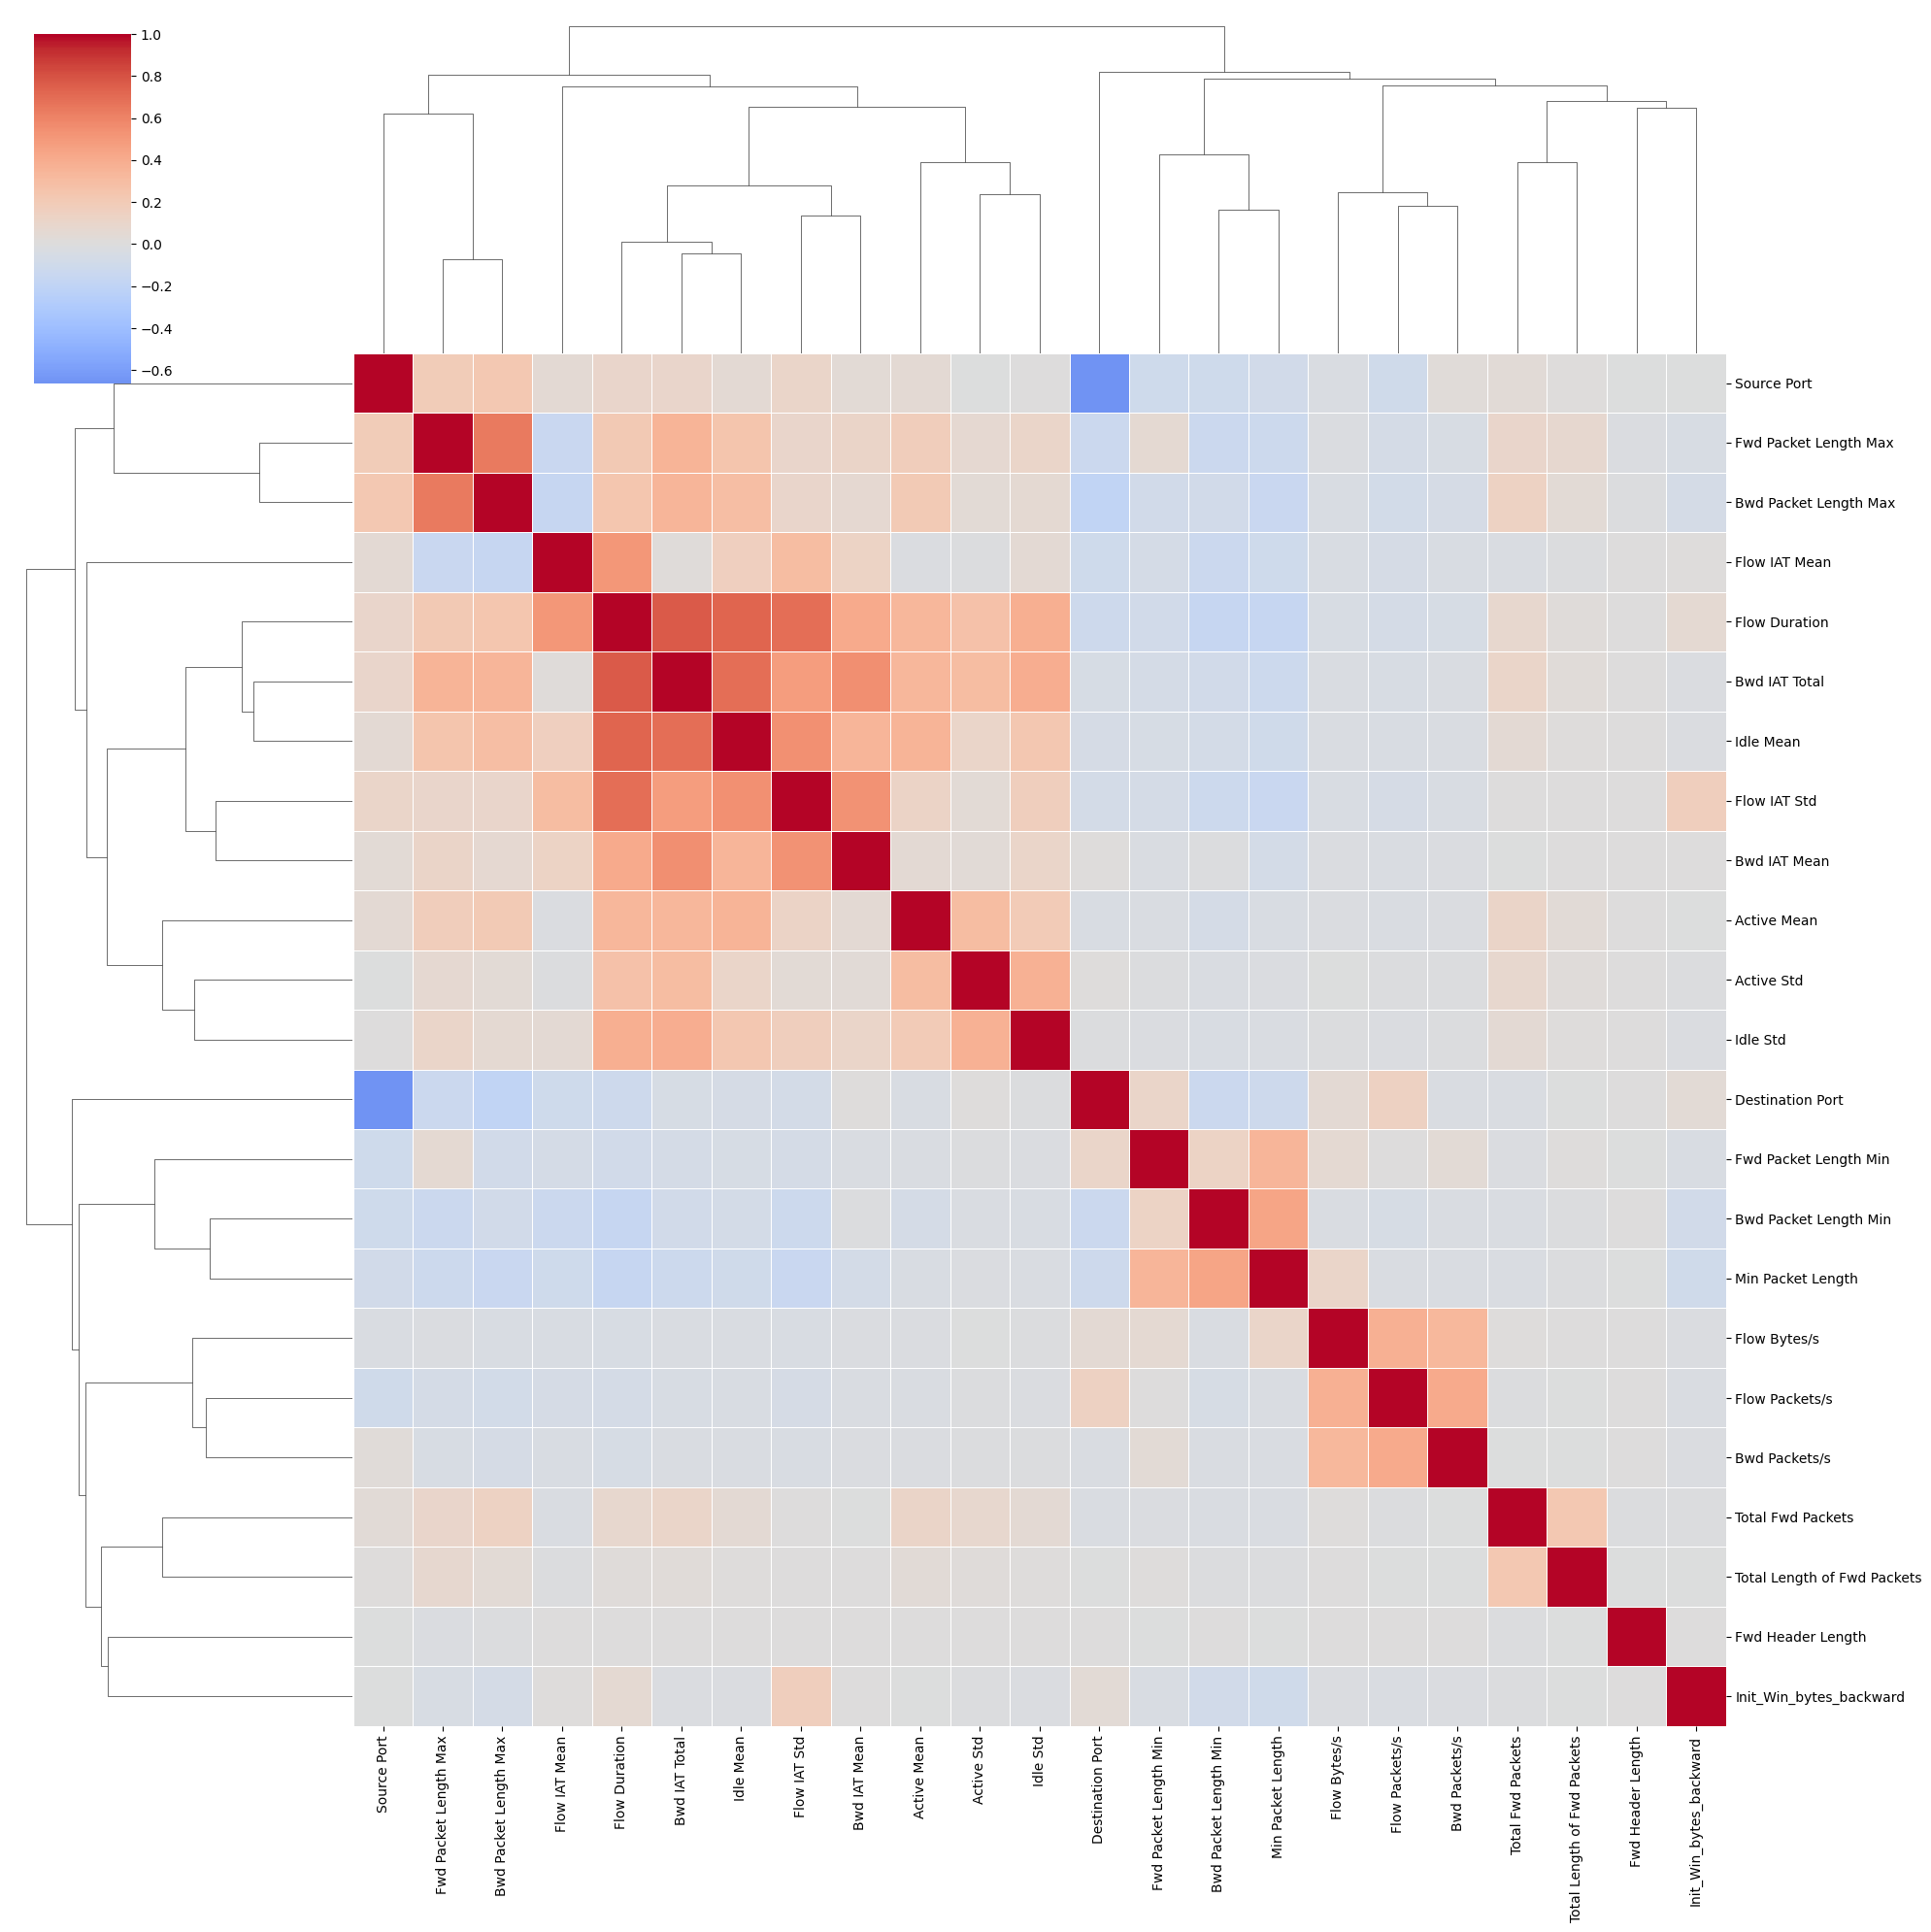

In [56]:
num_cols = x_train.select_dtypes(include="number")

filtered = num_cols.loc[:, 
    (num_cols.std() > 1) & 
    (num_cols.nunique() > 5)
]

corr = filtered.corr()

sns.clustermap(
    corr,
    cmap="coolwarm",
    figsize=(20, 20),
    center=0,
    linewidths=0.5,
    linecolor="white" 
)

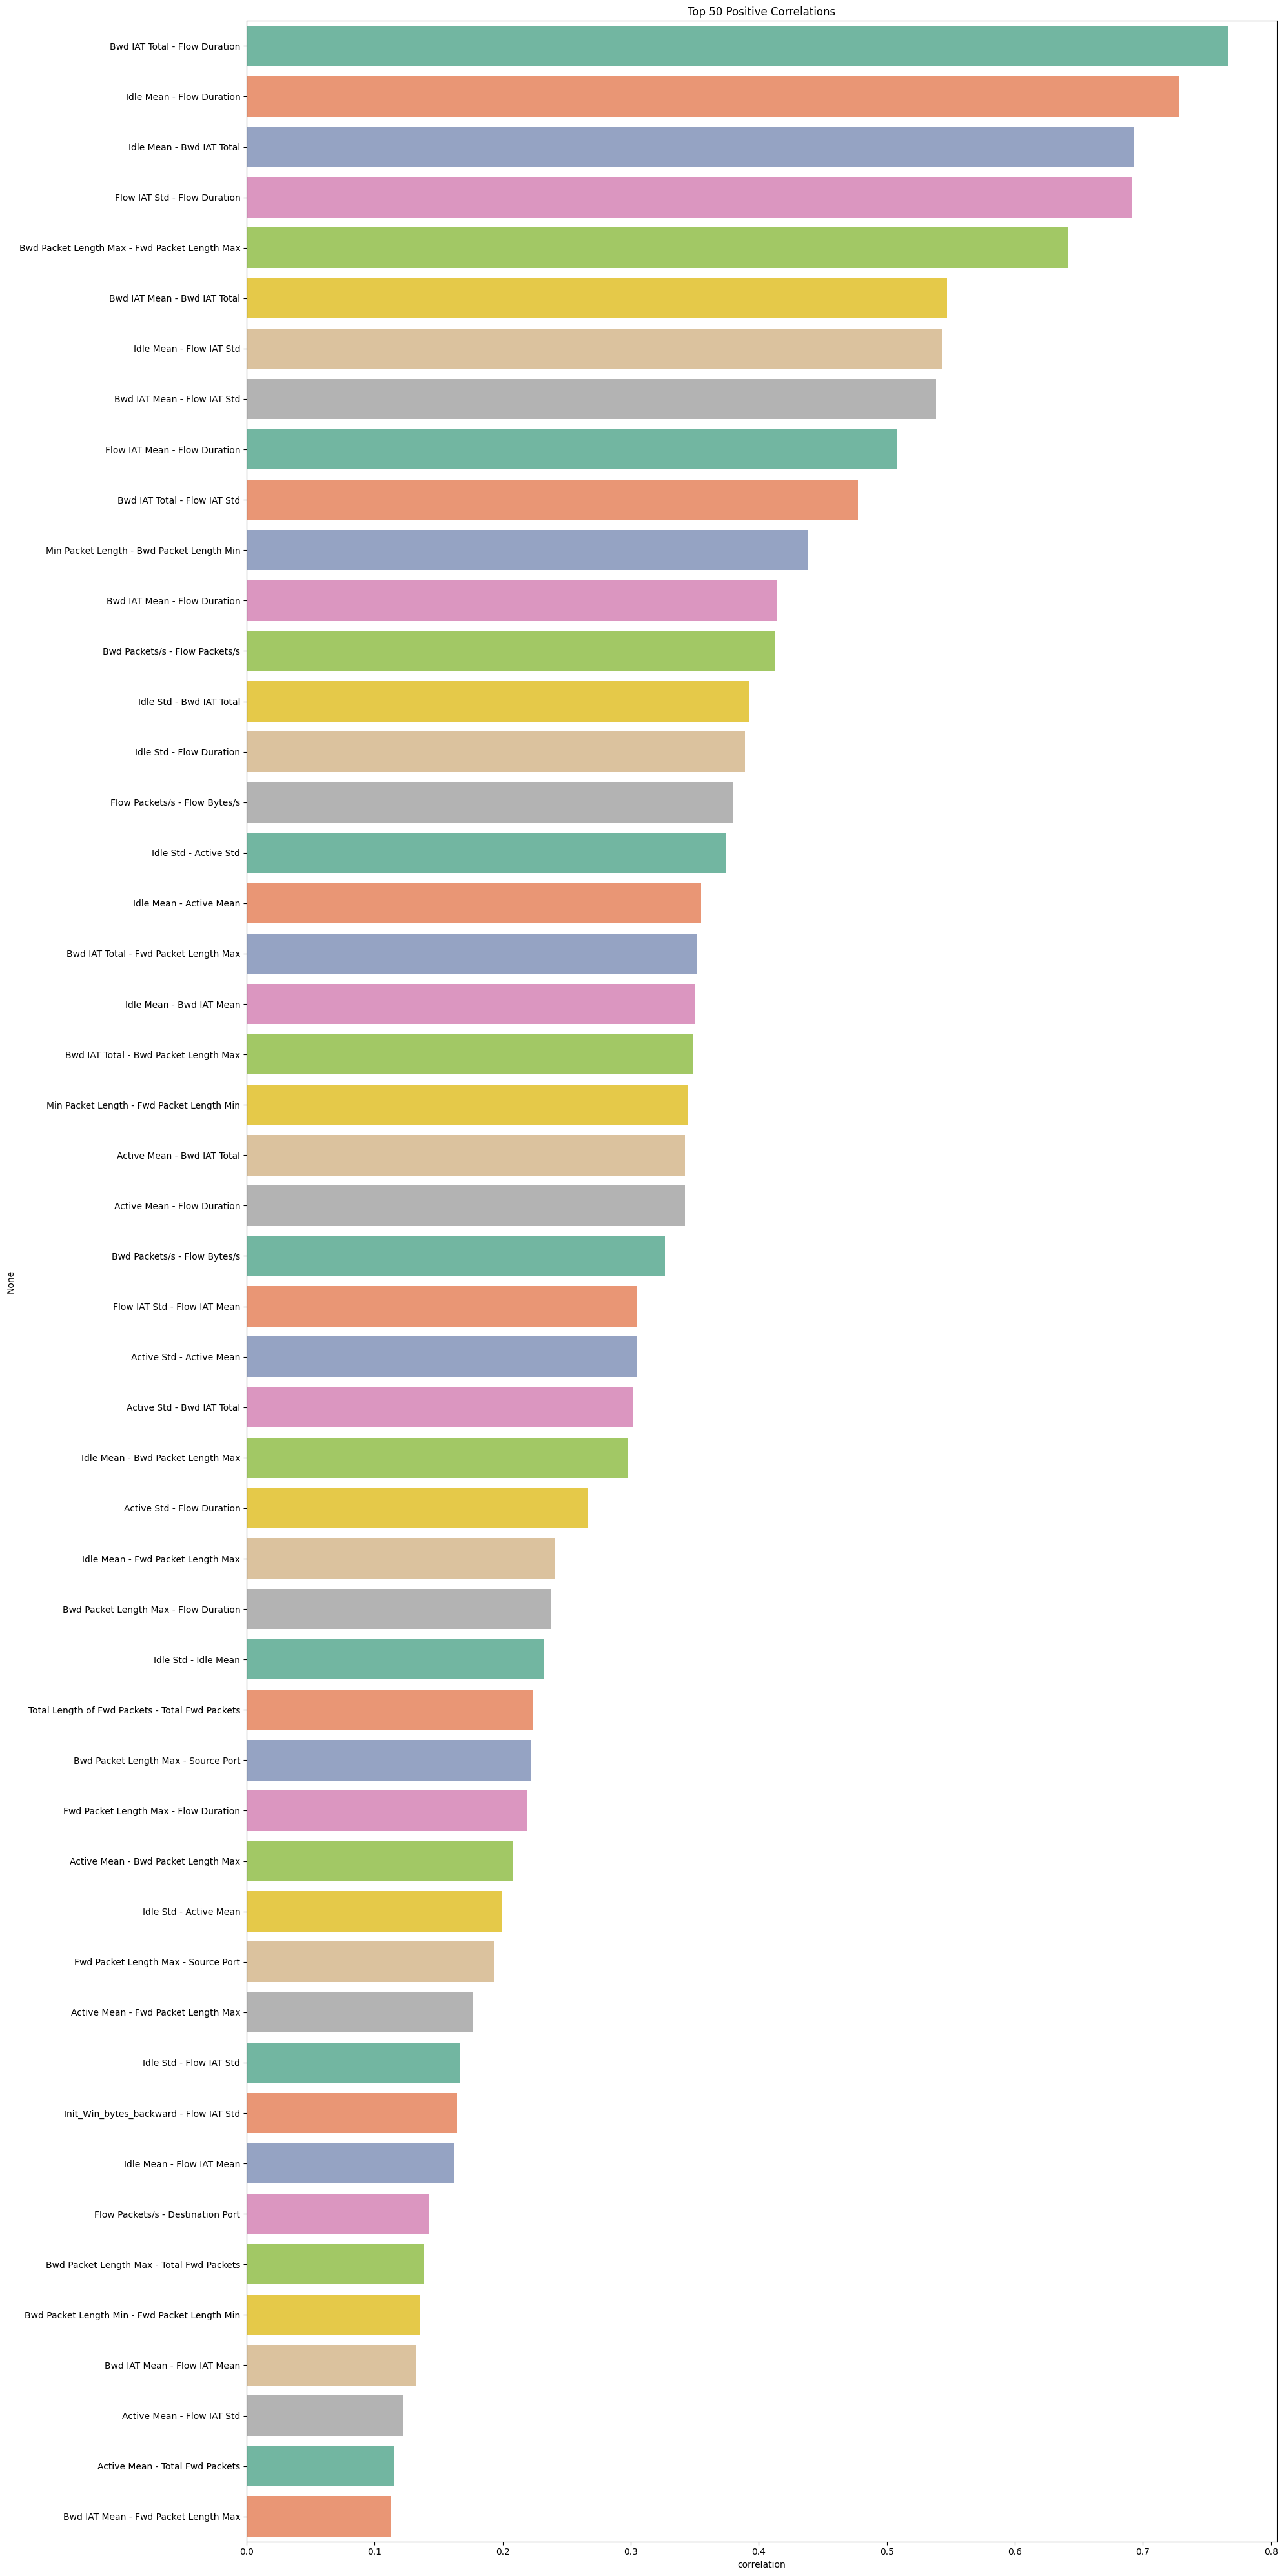

In [57]:
mask = np.tril(np.ones_like(corr, dtype=bool), k=-1)

corr_pairs = corr.where(mask).stack().reset_index()
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

top_positive = corr_pairs.sort_values("correlation", ascending=False).head(50)

plt.figure(figsize=(20, 40))

sns.barplot(
    data=top_positive,
    x="correlation",
    y=top_positive["feature_1"] + " - " + top_positive["feature_2"],
    hue=top_positive["feature_1"] + " - " + top_positive["feature_2"],
    palette="Set2"
)

plt.title("Top 50 Positive Correlations")
plt.tight_layout()
plt.show()

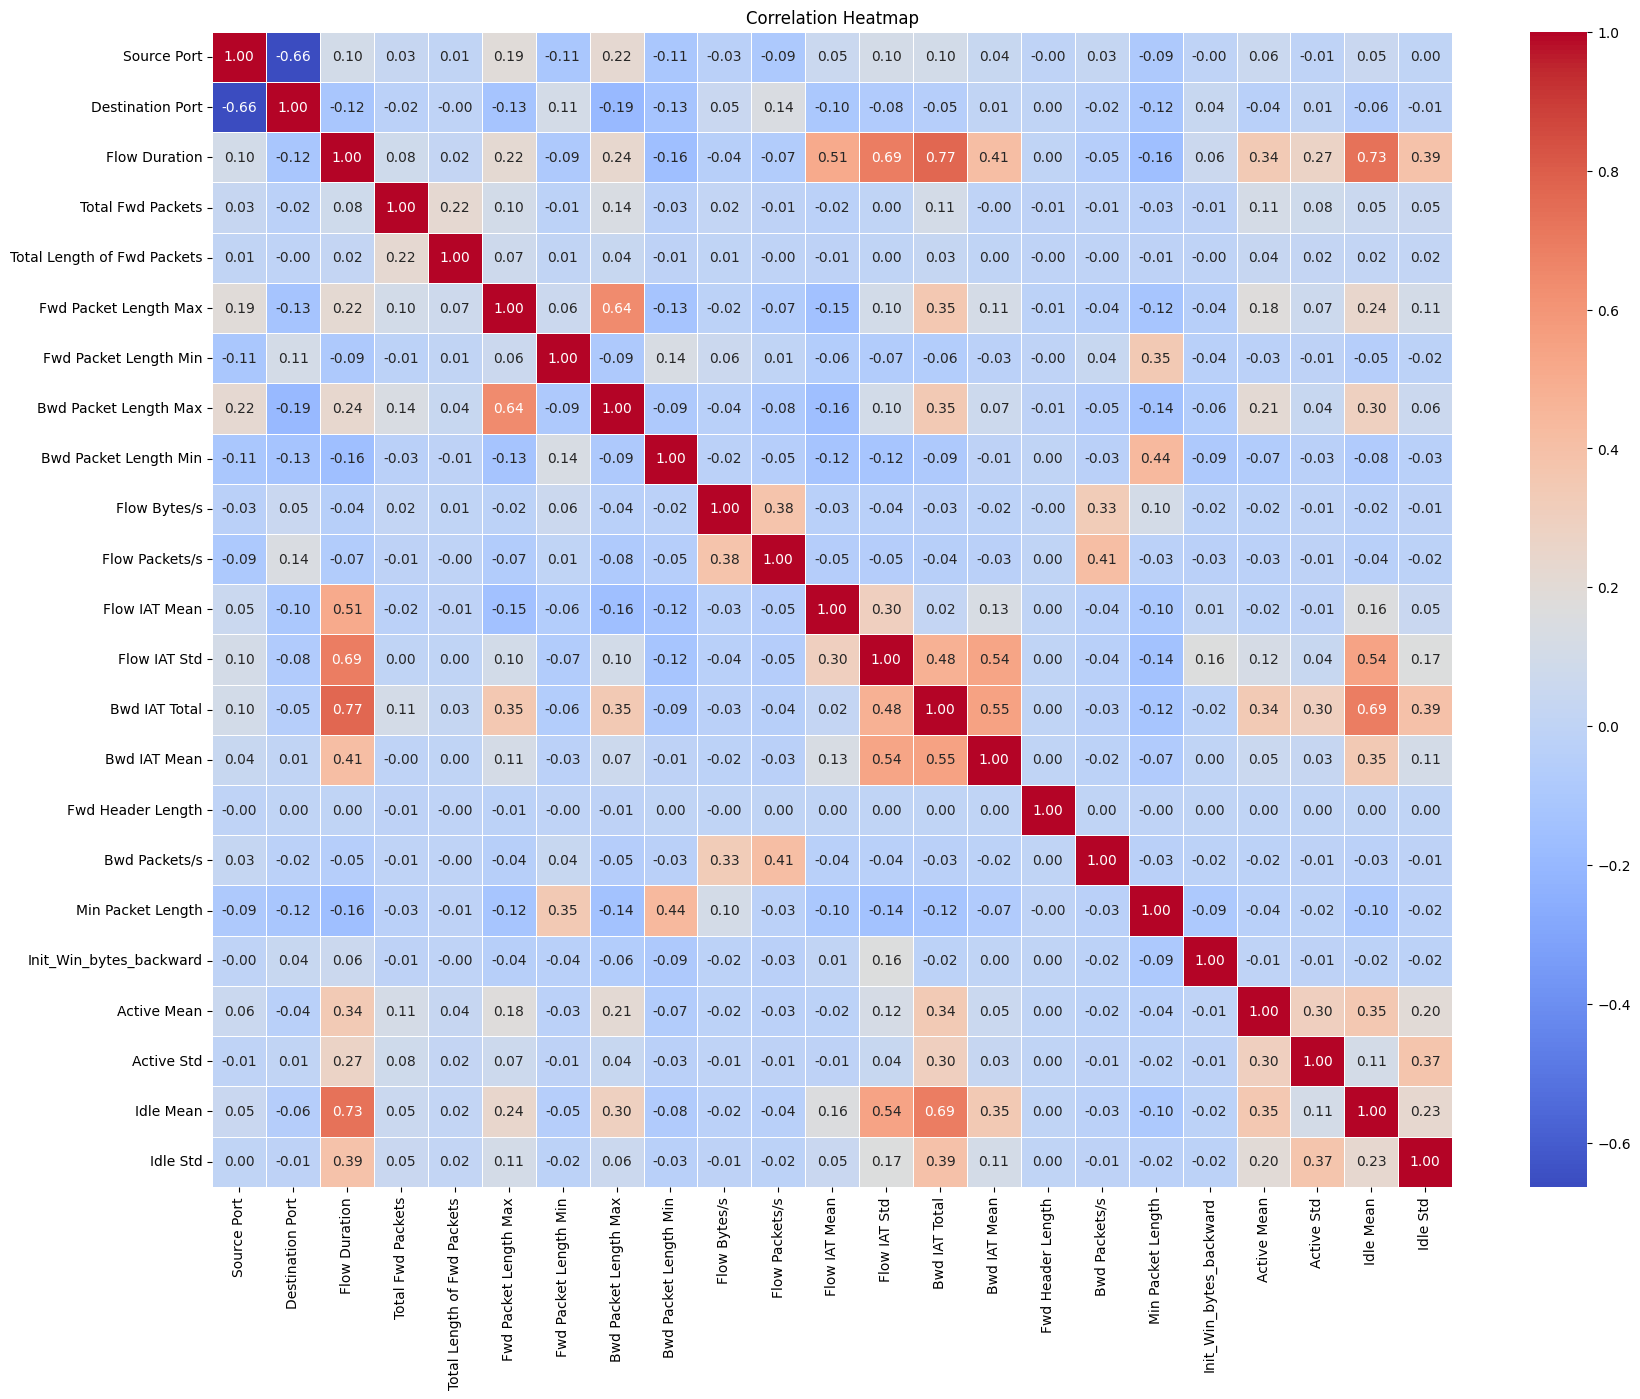

In [58]:
plt.figure(figsize=(20, 15))

sns.heatmap(
    corr,      
    cmap="coolwarm",  
    linewidths=0.5,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### 3.4. Kỹ thuật đặc trưng

#### 3.4.1. Biến Timestamp 

##### **a. Thực hiện trích dẫn ngày, tháng, năm, giờ, phút, ngày trong tuần trong biến Timestamp.**

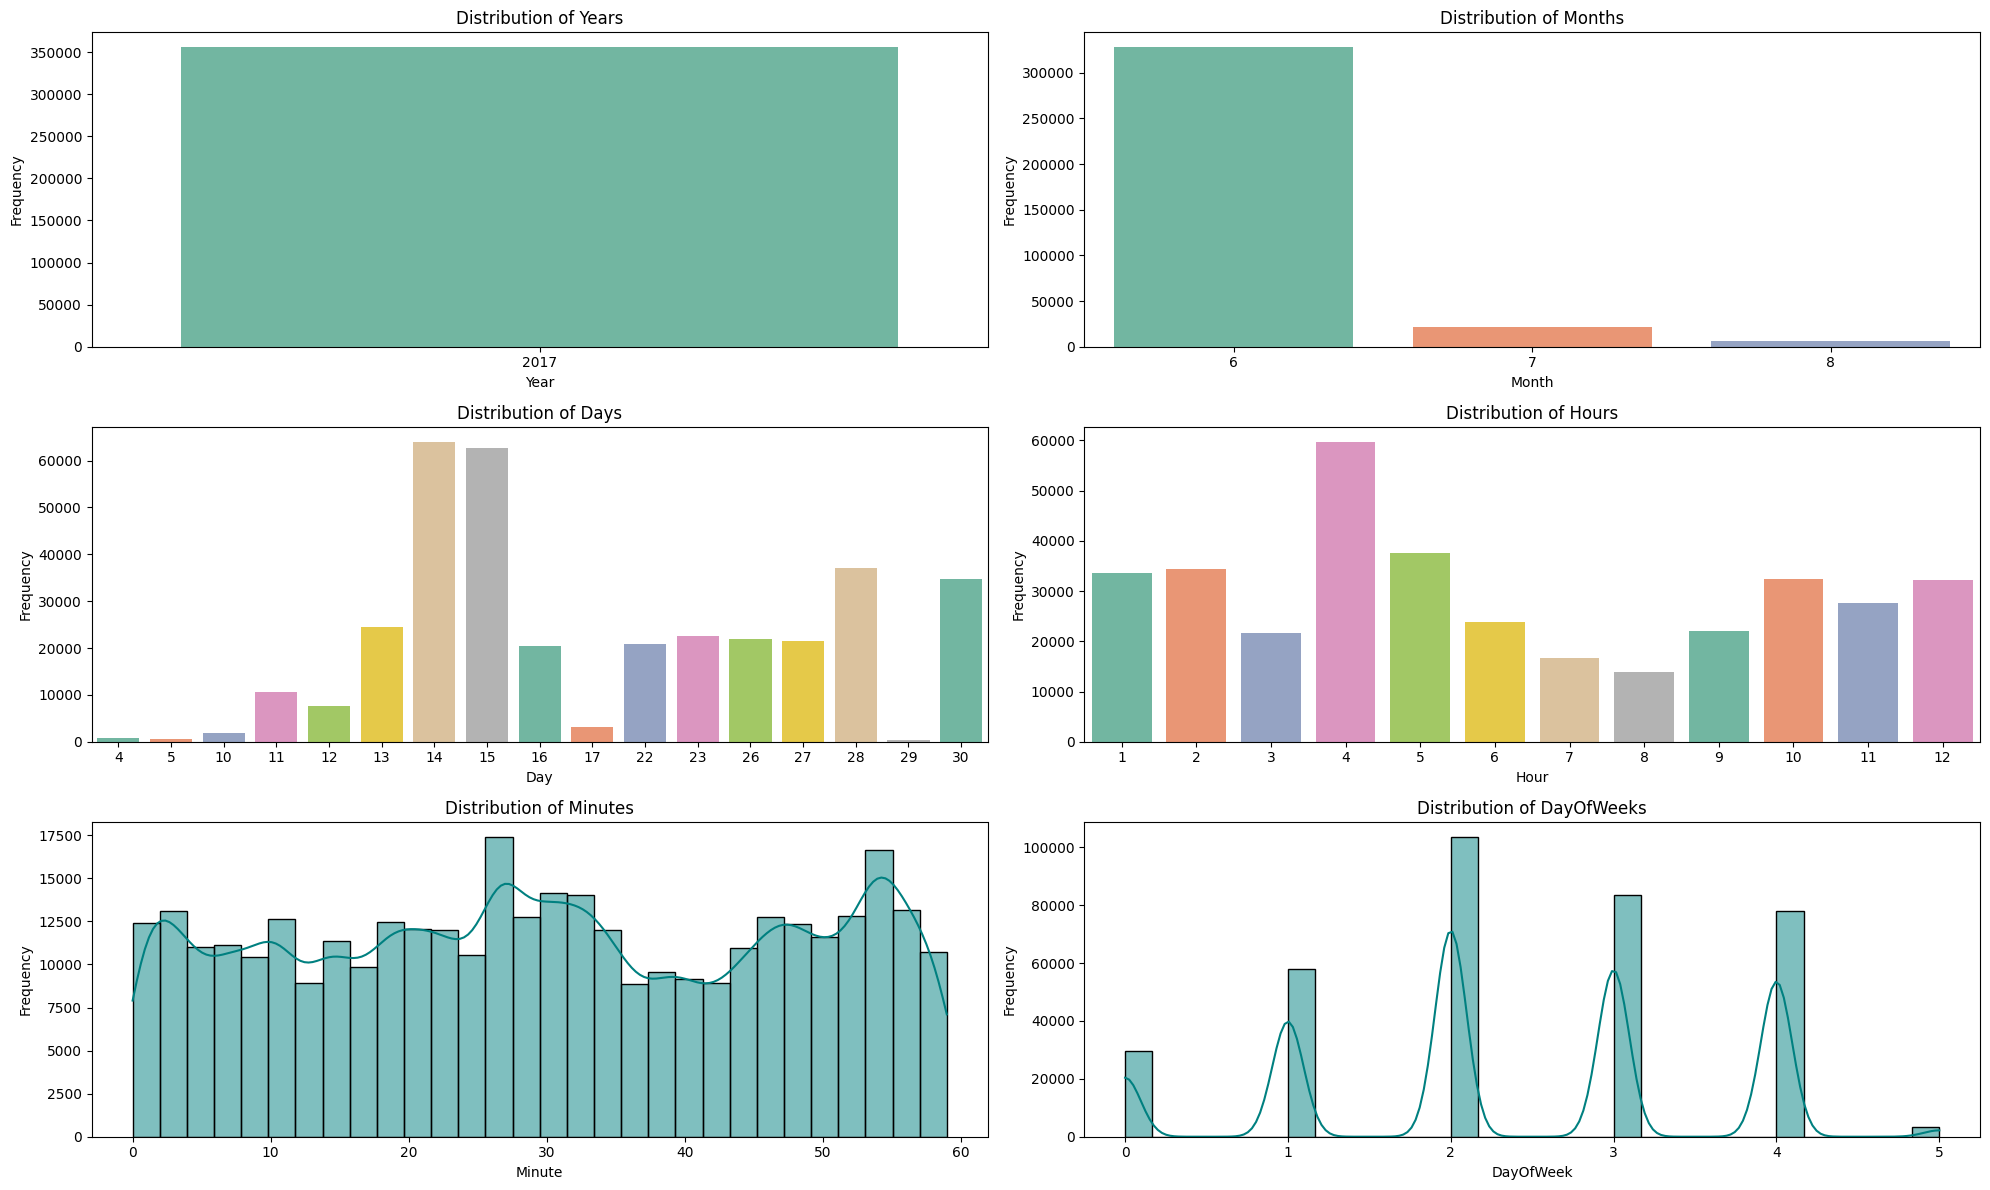

In [60]:

dt_series = pd.to_datetime(dataFrame["Timestamp"], format="%d/%m/%Y %H:%M:%S")

fig, axes = plt.subplots(3, 2, figsize=(20, 12))

features = {
    'Year': dt_series.dt.year,
    'Month': dt_series.dt.month,
    'Day': dt_series.dt.day,
    'Hour': dt_series.dt.hour,
    'Minute': dt_series.dt.minute,
    'DayOfWeek': dt_series.dt.dayofweek
}

# Loop through and create plots
for i, (name, data) in enumerate(features.items()):
    row, col = i // 2, i % 2
    
    if name in ['Year', 'Month', 'Day', 'Hour']:
        sns.countplot(x=data, ax=axes[row, col], palette='Set2', hue=data, legend=False)
    else:
        sns.histplot(data, bins=30, ax=axes[row, col], kde=True, color='teal')
    
    axes[row, col].set_title(f'Distribution of {name}s')
    axes[row, col].set_xlabel(name)
    axes[row, col].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Nhận xét:** Biến năm (Year), tháng (Month), phút (Minutes) có độ đo thời gian quá lớn hoặc quá nhỏ, có thể không lấy các biến này làm đặc trưng mới cho mô hình.

##### **b. Thực hiện lấy đặc trưng giờ (Hour), ngày (Day) và ngày trong tuần (DayOfWeek)**

In [61]:
def extract_time(df):
    temp_dt = pd.to_datetime(df["Timestamp"], format="%d/%m/%Y %H:%M:%S")

    df.insert(0, "Hour", temp_dt.dt.hour)
    df.insert(1, "Day", temp_dt.dt.day)
    df.insert(2, "DayOfWeek", temp_dt.dt.dayofweek)

    return df.drop(columns=["Timestamp"])

x_train = extract_time(x_train)
x_val = extract_time(x_val)
x_test = extract_time(x_test)

x_train.head()

,Hour,Day,DayOfWeek,Source IP,Source Port,Destination IP,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Bwd IAT Total,Bwd IAT Mean,Fwd PSH Flags,Fwd Header Length,Bwd Packets/s,Min Packet Length,FIN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Init_Win_bytes_backward,Active Mean,Active Std,Idle Mean,Idle Std
341993,5,16,4,202.77.129.150,80,10.42.0.151,38016.00,6.00,42,2,0.00,0.00,0.00,0.00,0.00,0.00,47619.05,42.00,0.00,0.00,0.00,0.00,40,0.00,0.00,0.00,0.00,1.00,0.00,0,-1.00,0.00,0.00,0.00,0.00
300839,1,30,4,10.42.0.151,45023,172.217.12.129,443.00,6.00,60047600,3,31.00,31.00,0.00,0.00,0.00,0.52,0.07,20015866.67,34558848.72,0.00,0.00,0.00,96,0.02,0.00,0.00,0.00,1.00,1.00,0,0.00,89987.00,0.00,59920976.00,0.00
242949,8,30,4,10.42.0.151,37948,42.56.76.21,80.00,6.00,6498903,2,0.00,0.00,0.00,0.00,0.00,0.00,0.31,6498903.00,0.00,0.00,0.00,0.00,64,0.00,0.00,0.00,0.00,1.00,1.00,0,-1.00,0.00,0.00,0.00,0.00
130533,11,15,3,10.42.0.211,43555,118.178.156.64,80.00,6.00,1746172,10,383.00,383.00,0.00,1460.00,0.00,5181.62,10.88,97009.56,216064.29,574885.00,71860.62,0.00,220,5.15,0.00,0.00,1.00,0.00,0.00,0,123.00,0.00,0.00,0.00,0.00
287524,6,11,1,10.42.0.211,40058,157.240.2.25,443.00,6.00,16823,2,0.00,0.00,0.00,0.00,0.00,0.00,118.88,16823.00,0.00,0.00,0.00,0.00,64,0.00,0.00,0.00,0.00,1.00,0.00,0,-1.00,0.00,0.00,0.00,0.00


#### 3.4.2. Biến Source ID và Destination IP
Các biến này có thể được xử lý bằng cách tách địa chỉ IP thành các bit nhị phân tương ứng. Ví dụ 192.168.1.0 được tách ra làm 32 cột có giá trị nhị phân tương ứng (11000000.10101000.00000001.00000000).

In [64]:
def unpack_ip_bits(df):

    df = df.copy()
    
    s_octets = df["Source IP"].str.split('.', expand=True).astype(np.uint8).values
    d_octets = df["Destination IP"].str.split('.', expand=True).astype(np.uint8).values

    source_bits = np.unpackbits(s_octets, axis=1)
    dest_bits = np.unpackbits(d_octets, axis=1)

    s_bit_cols = [f's_bit_{i}' for i in range(32)]
    d_bit_cols = [f'd_bit_{i}' for i in range(32)]

    df_bits_s = pd.DataFrame(source_bits, columns=s_bit_cols, index=df.index)
    df_bits_d = pd.DataFrame(dest_bits, columns=d_bit_cols, index=df.index)

    df = pd.concat([df, df_bits_s, df_bits_d], axis=1)
    df = df.drop(columns=["Source IP", "Destination IP"])
    
    return df

In [65]:
x_train = unpack_ip_bits(x_train)
x_val = unpack_ip_bits(x_val)
x_test = unpack_ip_bits(x_test)

x_train.head()
print(x_train.shape[1] == x_val.shape[1] == x_test.shape[1])

True


#### 3.4.3. Biến Source Port và Destination Port
Các biến này có thể được xử lý bằng cách tách ra thành các biến OneHot với các nhóm tương ứng theo định nghĩa của mạng máy tính, bao gồm 3 loại chính: System Ports (0-1023), Registered Ports (1024–49151), Dynamic Ports (49152–65535). Các port xuất hiện nhiều như 80 (HTTP), 443 (HTTPS), 53 (DNS), 0 (Reserved), 1900 (SSDP) có thể được OneHot để mô hình phân loại dễ hơn.

In [ ]:
x_train["Source Port"].to_frame().value_counts().head(40).to_dict()

{(443,): 15883,
 (80,): 11044,
 (0,): 1737,
 (60774,): 1207,
 (43477,): 595,
 (5353,): 265,
 (5222,): 237,
 (46360,): 162,
 (8612,): 158,
 (5228,): 144,
 (12350,): 110,
 (68,): 67,
 (40010,): 58,
 (40019,): 56,
 (30320,): 43,
 (47484,): 37,
 (9999,): 35,
 (47966,): 34,
 (43277,): 34,
 (40342,): 34,
 (98,): 32,
 (37016,): 31,
 (36598,): 31,
 (34730,): 31,
 (51626,): 30,
 (33614,): 30,
 (34508,): 29,
 (46389,): 29,
 (48989,): 29,
 (34472,): 29,
 (47070,): 28,
 (47782,): 28,
 (48743,): 28,
 (58087,): 28,
 (57551,): 28,
 (49202,): 28,
 (38998,): 27,
 (35072,): 27,
 (52026,): 27,
 (42684,): 27}

In [ ]:
x_train["Destination Port"].to_frame().value_counts().head(20).to_dict()

{(443.0,): 110925,
 (80.0,): 81235,
 (53.0,): 53731,
 (0.0,): 1737,
 (1900.0,): 1414,
 (5228.0,): 698,
 (5222.0,): 637,
 (7017.0,): 530,
 (9999.0,): 519,
 (9998.0,): 492,
 (123.0,): 376,
 (5351.0,): 317,
 (5353.0,): 265,
 (40024.0,): 238,
 (40015.0,): 209,
 (40019.0,): 186,
 (9230.0,): 175,
 (8080.0,): 159,
 (8977.0,): 154,
 (40022.0,): 149}

In [66]:
def group_ports(df, column_name):
    bins = [-1, 1023, 49151, 65535]
    labels = ['System', 'Registered', 'Dynamic']
    
    temp_col = f"{column_name}_temp"
    df[temp_col] = pd.cut(df[column_name], bins=bins, labels=labels)
    
    df = pd.get_dummies(df, columns=[temp_col], prefix=f"{column_name}_Grp", dtype=int)
    
    return df

x_train = group_ports(x_train, "Source Port")
x_train = group_ports(x_train, "Destination Port")
x_val = group_ports(x_val, "Source Port")
x_val = group_ports(x_val, "Destination Port")
x_test = group_ports(x_test, "Source Port")
x_test = group_ports(x_test, "Destination Port")

x_train.head()
print(x_train.shape[1] == x_val.shape[1] == x_test.shape[1])

True


In [67]:
def extract_popular_ports(df, column_name):

    popular_ports = {
        80: 'HTTP', 443: 'HTTPS', 53: 'DNS', 
        0: 'Reserved', 1900: 'SSDP'
    }

    def map_port(port):
        if port in popular_ports:
            return popular_ports[port]
        elif port <= 1023:
            return 'Other_System'
        elif port <= 49151:
            return 'Other_Registered'
        else:
            return 'Dynamic'

    all_categories = list(popular_ports.values()) + ['Other_System', 'Other_Registered', 'Dynamic']
    temp_col = f"{column_name}_temp"
    mapped_series = df[column_name].apply(map_port)
    df[temp_col] = pd.Categorical(mapped_series, categories=all_categories)
    df = pd.get_dummies(df, columns=[temp_col], prefix=f"{column_name}_Flag", dtype=int)
    
    return df


x_train = extract_popular_ports(x_train, "Destination Port")
x_train = x_train.drop(columns=["Source Port", "Destination Port"])

x_val = extract_popular_ports(x_val, "Destination Port")
x_val = x_val.drop(columns=["Source Port", "Destination Port"])

x_test = extract_popular_ports(x_test, "Destination Port")
x_test = x_test.drop(columns=["Source Port", "Destination Port"])

print(x_train.shape[1] == x_val.shape[1] == x_test.shape[1])
x_train.head()

True


,Hour,Day,DayOfWeek,Protocol,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Bwd IAT Total,Bwd IAT Mean,Fwd PSH Flags,Fwd Header Length,Bwd Packets/s,Min Packet Length,FIN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Init_Win_bytes_backward,Active Mean,Active Std,Idle Mean,Idle Std,s_bit_0,s_bit_1,s_bit_2,s_bit_3,s_bit_4,s_bit_5,s_bit_6,s_bit_7,s_bit_8,s_bit_9,s_bit_10,s_bit_11,s_bit_12,s_bit_13,s_bit_14,s_bit_15,s_bit_16,s_bit_17,s_bit_18,s_bit_19,s_bit_20,s_bit_21,s_bit_22,s_bit_23,s_bit_24,s_bit_25,s_bit_26,s_bit_27,s_bit_28,s_bit_29,s_bit_30,s_bit_31,d_bit_0,d_bit_1,d_bit_2,d_bit_3,d_bit_4,d_bit_5,d_bit_6,d_bit_7,d_bit_8,d_bit_9,d_bit_10,d_bit_11,d_bit_12,d_bit_13,d_bit_14,d_bit_15,d_bit_16,d_bit_17,d_bit_18,d_bit_19,d_bit_20,d_bit_21,d_bit_22,d_bit_23,d_bit_24,d_bit_25,d_bit_26,d_bit_27,d_bit_28,d_bit_29,d_bit_30,d_bit_31,Source Port_Grp_System,Source Port_Grp_Registered,Source Port_Grp_Dynamic,Destination Port_Grp_System,Destination Port_Grp_Registered,Destination Port_Grp_Dynamic,Destination Port_Flag_HTTP,Destination Port_Flag_HTTPS,Destination Port_Flag_DNS,Destination Port_Flag_Reserved,Destination Port_Flag_SSDP,Destination Port_Flag_Other_System,Destination Port_Flag_Other_Registered,Destination Port_Flag_Dynamic
341993,5,16,4,6.00,42,2,0.00,0.00,0.00,0.00,0.00,0.00,47619.05,42.00,0.00,0.00,0.00,0.00,40,0.00,0.00,0.00,0.00,1.00,0.00,0,-1.00,0.00,0.00,0.00,0.00,1,1,0,0,1,0,1,0,0,1,0,0,1,1,0,1,1,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0
300839,1,30,4,6.00,60047600,3,31.00,31.00,0.00,0.00,0.00,0.52,0.07,20015866.67,34558848.72,0.00,0.00,0.00,96,0.02,0.00,0.00,0.00,1.00,1.00,0,0.00,89987.00,0.00,59920976.00,0.00,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,1,0,1,1,0,0,1,1,0,1,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0
242949,8,30,4,6.00,6498903,2,0.00,0.00,0.00,0.00,0.00,0.00,0.31,6498903.00,0.00,0.00,0.00,0.00,64,0.00,0.00,0.00,0.00,1.00,1.00,0,-1.00,0.00,0.00,0.00,0.00,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,0,0,1,0,1,0,1,0,0,0,1,1,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,0,1,0,0,0,0,0,0,0
130533,11,15,3,6.00,1746172,10,383.00,383.00,0.00,1460.00,0.00,5181.62,10.88,97009.56,216064.29,574885.00,71860.62,0.00,220,5.15,0.00,0.00,1.00,0.00,0.00,0,123.00,0.00,0.00,0.00,0.00,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,0,1,1,1,0,1,1,0,1,0,1,1,0,0,1,0,1,0,0,1,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0
287524,6,11,1,6.00,16823,2,0.00,0.00,0.00,0.00,0.00,0.00,118.88,16823.00,0.00,0.00,0.00,0.00,64,0.00,0.00,0.00,0.00,1.00,0.00,0,-1.00,0.00,0.00,0.00,0.00,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,1,0,0,1,1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0


#### 3.4.4. Cyclic encoding cho các biến có mối quan hệ tuần hoàn
Các biến ngày (Day) và giờ (Hour) có quan hệ tuần hoàn và cần được xử lý bằng cyclic encoding để giúp các mô hình hiểu mối quan hệ tuần hoàn của các biến này.

In [68]:
def encode_cyclical(df):
    df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 12)
    df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 12)
    
    df["Day_sin"] = np.sin(2 * np.pi * df["Hour"] / 31)
    df["Day_cos"] = np.cos(2 * np.pi * df["Hour"] / 31)
  
    df = df.drop(columns=["Hour", "Day"])
        
    return df

x_train = encode_cyclical(x_train)
x_val = encode_cyclical(x_val)
x_test = encode_cyclical(x_test)

print(x_train.shape[1] == x_val.shape[1] == x_test.shape[1])
x_train.head()

True


,DayOfWeek,Protocol,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Bwd IAT Total,Bwd IAT Mean,Fwd PSH Flags,Fwd Header Length,Bwd Packets/s,Min Packet Length,FIN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Init_Win_bytes_backward,Active Mean,Active Std,Idle Mean,Idle Std,s_bit_0,s_bit_1,s_bit_2,s_bit_3,s_bit_4,s_bit_5,s_bit_6,s_bit_7,s_bit_8,s_bit_9,s_bit_10,s_bit_11,s_bit_12,s_bit_13,s_bit_14,s_bit_15,s_bit_16,s_bit_17,s_bit_18,s_bit_19,s_bit_20,s_bit_21,s_bit_22,s_bit_23,s_bit_24,s_bit_25,s_bit_26,s_bit_27,s_bit_28,s_bit_29,s_bit_30,s_bit_31,d_bit_0,d_bit_1,d_bit_2,d_bit_3,d_bit_4,d_bit_5,d_bit_6,d_bit_7,d_bit_8,d_bit_9,d_bit_10,d_bit_11,d_bit_12,d_bit_13,d_bit_14,d_bit_15,d_bit_16,d_bit_17,d_bit_18,d_bit_19,d_bit_20,d_bit_21,d_bit_22,d_bit_23,d_bit_24,d_bit_25,d_bit_26,d_bit_27,d_bit_28,d_bit_29,d_bit_30,d_bit_31,Source Port_Grp_System,Source Port_Grp_Registered,Source Port_Grp_Dynamic,Destination Port_Grp_System,Destination Port_Grp_Registered,Destination Port_Grp_Dynamic,Destination Port_Flag_HTTP,Destination Port_Flag_HTTPS,Destination Port_Flag_DNS,Destination Port_Flag_Reserved,Destination Port_Flag_SSDP,Destination Port_Flag_Other_System,Destination Port_Flag_Other_Registered,Destination Port_Flag_Dynamic,Hour_sin,Hour_cos,Day_sin,Day_cos
341993,4,6.00,42,2,0.00,0.00,0.00,0.00,0.00,0.00,47619.05,42.00,0.00,0.00,0.00,0.00,40,0.00,0.00,0.00,0.00,1.00,0.00,0,-1.00,0.00,0.00,0.00,0.00,1,1,0,0,1,0,1,0,0,1,0,0,1,1,0,1,1,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0.50,-0.87,0.85,0.53
300839,4,6.00,60047600,3,31.00,31.00,0.00,0.00,0.00,0.52,0.07,20015866.67,34558848.72,0.00,0.00,0.00,96,0.02,0.00,0.00,0.00,1.00,1.00,0,0.00,89987.00,0.00,59920976.00,0.00,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,1,0,1,1,0,0,1,1,0,1,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0.50,0.87,0.20,0.98
242949,4,6.00,6498903,2,0.00,0.00,0.00,0.00,0.00,0.00,0.31,6498903.00,0.00,0.00,0.00,0.00,64,0.00,0.00,0.00,0.00,1.00,1.00,0,-1.00,0.00,0.00,0.00,0.00,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,0,0,1,0,1,0,1,0,0,0,1,1,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,0,1,0,0,0,0,0,0,0,-0.87,-0.50,1.00,-0.05
130533,3,6.00,1746172,10,383.00,383.00,0.00,1460.00,0.00,5181.62,10.88,97009.56,216064.29,574885.00,71860.62,0.00,220,5.15,0.00,0.00,1.00,0.00,0.00,0,123.00,0.00,0.00,0.00,0.00,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,0,1,1,1,0,1,1,0,1,0,1,1,0,0,1,0,1,0,0,1,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,-0.50,0.87,0.79,-0.61
287524,1,6.00,16823,2,0.00,0.00,0.00,0.00,0.00,0.00,118.88,16823.00,0.00,0.00,0.00,0.00,64,0.00,0.00,0.00,0.00,1.00,0.00,0,-1.00,0.00,0.00,0.00,0.00,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,1,0,0,1,1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0.00,-1.00,0.94,0.35


#### 3.4.5. Thực hiện OneHot Encoding cho các biến Protocol và DayOfWeek

In [69]:
num_cols = x_train.select_dtypes(include="number")

filtered = num_cols.loc[:, 
    (num_cols.nunique() < 100)
]

filtered.head()

,DayOfWeek,Protocol,Fwd PSH Flags,Min Packet Length,FIN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,s_bit_0,s_bit_1,s_bit_2,s_bit_3,s_bit_4,s_bit_5,s_bit_6,s_bit_7,s_bit_8,s_bit_9,s_bit_10,s_bit_11,s_bit_12,s_bit_13,s_bit_14,s_bit_15,s_bit_16,s_bit_17,s_bit_18,s_bit_19,s_bit_20,s_bit_21,s_bit_22,s_bit_23,s_bit_24,s_bit_25,s_bit_26,s_bit_27,s_bit_28,s_bit_29,s_bit_30,s_bit_31,d_bit_0,d_bit_1,d_bit_2,d_bit_3,d_bit_4,d_bit_5,d_bit_6,d_bit_7,d_bit_8,d_bit_9,d_bit_10,d_bit_11,d_bit_12,d_bit_13,d_bit_14,d_bit_15,d_bit_16,d_bit_17,d_bit_18,d_bit_19,d_bit_20,d_bit_21,d_bit_22,d_bit_23,d_bit_24,d_bit_25,d_bit_26,d_bit_27,d_bit_28,d_bit_29,d_bit_30,d_bit_31,Source Port_Grp_System,Source Port_Grp_Registered,Source Port_Grp_Dynamic,Destination Port_Grp_System,Destination Port_Grp_Registered,Destination Port_Grp_Dynamic,Destination Port_Flag_HTTP,Destination Port_Flag_HTTPS,Destination Port_Flag_DNS,Destination Port_Flag_Reserved,Destination Port_Flag_SSDP,Destination Port_Flag_Other_System,Destination Port_Flag_Other_Registered,Destination Port_Flag_Dynamic,Hour_sin,Hour_cos,Day_sin,Day_cos
341993,4,6.00,0.00,0.00,0.00,0.00,1.00,0.00,0,1,1,0,0,1,0,1,0,0,1,0,0,1,1,0,1,1,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0.50,-0.87,0.85,0.53
300839,4,6.00,0.00,0.00,0.00,0.00,1.00,1.00,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,1,0,1,1,0,0,1,1,0,1,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0.50,0.87,0.20,0.98
242949,4,6.00,0.00,0.00,0.00,0.00,1.00,1.00,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,0,0,1,0,1,0,1,0,0,0,1,1,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,0,1,0,0,0,0,0,0,0,-0.87,-0.50,1.00,-0.05
130533,3,6.00,0.00,0.00,0.00,1.00,0.00,0.00,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,0,1,1,1,0,1,1,0,1,0,1,1,0,0,1,0,1,0,0,1,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,-0.50,0.87,0.79,-0.61
287524,1,6.00,0.00,0.00,0.00,0.00,1.00,0.00,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,1,0,0,1,1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0.00,-1.00,0.94,0.35


In [70]:
cols = ["Protocol", "DayOfWeek"]

encoder = OneHotEncoder(sparse_output=False, dtype=np.int8, handle_unknown="ignore")
encoded_array = encoder.fit_transform(x_train[cols])

def apply_one_hot(df, encoder, cols):
    encoded = encoder.transform(df[cols])
    encoded_df = pd.DataFrame(
        encoded,
        columns=encoder.get_feature_names_out(cols),
        index=df.index
    )
    return pd.concat([df.drop(columns=cols), encoded_df], axis=1)

x_train = apply_one_hot(x_train, encoder, cols)
x_val   = apply_one_hot(x_val, encoder, cols)
x_test  = apply_one_hot(x_test, encoder, cols)

print(x_train.shape[1] == x_val.shape[1] == x_test.shape[1])
x_train.head()

True


,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Bwd IAT Total,Bwd IAT Mean,Fwd PSH Flags,Fwd Header Length,Bwd Packets/s,Min Packet Length,FIN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Init_Win_bytes_backward,Active Mean,Active Std,Idle Mean,Idle Std,s_bit_0,s_bit_1,s_bit_2,s_bit_3,s_bit_4,s_bit_5,s_bit_6,s_bit_7,s_bit_8,s_bit_9,s_bit_10,s_bit_11,s_bit_12,s_bit_13,s_bit_14,s_bit_15,s_bit_16,s_bit_17,s_bit_18,s_bit_19,s_bit_20,s_bit_21,s_bit_22,s_bit_23,s_bit_24,s_bit_25,s_bit_26,s_bit_27,s_bit_28,s_bit_29,s_bit_30,s_bit_31,d_bit_0,d_bit_1,d_bit_2,d_bit_3,d_bit_4,d_bit_5,d_bit_6,d_bit_7,d_bit_8,d_bit_9,d_bit_10,d_bit_11,d_bit_12,d_bit_13,d_bit_14,d_bit_15,d_bit_16,d_bit_17,d_bit_18,d_bit_19,d_bit_20,d_bit_21,d_bit_22,d_bit_23,d_bit_24,d_bit_25,d_bit_26,d_bit_27,d_bit_28,d_bit_29,d_bit_30,d_bit_31,Source Port_Grp_System,Source Port_Grp_Registered,Source Port_Grp_Dynamic,Destination Port_Grp_System,Destination Port_Grp_Registered,Destination Port_Grp_Dynamic,Destination Port_Flag_HTTP,Destination Port_Flag_HTTPS,Destination Port_Flag_DNS,Destination Port_Flag_Reserved,Destination Port_Flag_SSDP,Destination Port_Flag_Other_System,Destination Port_Flag_Other_Registered,Destination Port_Flag_Dynamic,Hour_sin,Hour_cos,Day_sin,Day_cos,Protocol_0.0,Protocol_6.0,Protocol_17.0,DayOfWeek_0,DayOfWeek_1,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5
341993,42,2,0.00,0.00,0.00,0.00,0.00,0.00,47619.05,42.00,0.00,0.00,0.00,0.00,40,0.00,0.00,0.00,0.00,1.00,0.00,0,-1.00,0.00,0.00,0.00,0.00,1,1,0,0,1,0,1,0,0,1,0,0,1,1,0,1,1,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0.50,-0.87,0.85,0.53,0,1,0,0,0,0,0,1,0
300839,60047600,3,31.00,31.00,0.00,0.00,0.00,0.52,0.07,20015866.67,34558848.72,0.00,0.00,0.00,96,0.02,0.00,0.00,0.00,1.00,1.00,0,0.00,89987.00,0.00,59920976.00,0.00,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,1,0,1,1,0,0,1,1,0,1,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0.50,0.87,0.20,0.98,0,1,0,0,0,0,0,1,0
242949,6498903,2,0.00,0.00,0.00,0.00,0.00,0.00,0.31,6498903.00,0.00,0.00,0.00,0.00,64,0.00,0.00,0.00,0.00,1.00,1.00,0,-1.00,0.00,0.00,0.00,0.00,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,0,0,1,0,1,0,1,0,0,0,1,1,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,0,1,0,0,0,0,0,0,0,-0.87,-0.50,1.00,-0.05,0,1,0,0,0,0,0,1,0
130533,1746172,10,383.00,383.00,0.00,1460.00,0.00,5181.62,10.88,97009.56,216064.29,574885.00,71860.62,0.00,220,5.15,0.00,0.00,1.00,0.00,0.00,0,123.00,0.00,0.00,0.00,0.00,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,0,1,1,1,0,1,1,0,1,0,1,1,0,0,1,0,1,0,0,1,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,-0.50,0.87,0.79,-0.61,0,1,0,0,0,0,1,0,0
287524,16823,2,0.00,0.00,0.00,0.00,0.00,0.00,118.88,16823.00,0.00,0.00,0.00,0.00,64,0.00,0.00,0.00,0.00,1.00,0.00,0,-1.00,0.00,0.00,0.00,0.00,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,1,0,0,1,1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0.00,-1.00,0.94,0.35,0,1,0,0,1,0,0,0,0


#### 3.4.6. Xử lý các biến có phân bố âm 
Một số biến có tồn tại giá trị âm, cần thực hiện đưa về giá trị 0. Biến Init_Win_bytes_backward có nhiều giá trị âm nên cần được thêm biến OneHot Missing mới để tránh mất thông tin dữ liệu.

In [71]:
negative_cols = x_train.columns[(x_train.min() < 0)].tolist()

print(f"Found {len(negative_cols)} columns with negative values of train data:")
print(x_train[negative_cols].agg(['min', 'mean', 'count']))

negative_cols = x_val.columns[(x_val.min() < 0)].tolist()

print(f"\nFound {len(negative_cols)} columns with negative values of validation data:")
print(x_val[negative_cols].agg(['min', 'mean', 'count']))

negative_cols = x_test.columns[(x_test.min() < 0)].tolist()

print(f"\nFound {len(negative_cols)} columns with negative values of test data:")
print(x_test[negative_cols].agg(['min', 'mean', 'count']))

Found 8 columns with negative values of train data:
       Flow Duration  Flow Packets/s  Flow IAT Mean  Fwd Header Length  \
min            -1.00     -2000000.00          -1.00    -75333323990.00   
mean     10943088.14         5521.34     3179751.26        -1019040.60   
count      284500.00       284500.00      284500.00          284500.00   

       Init_Win_bytes_backward  Hour_sin  Hour_cos   Day_cos  
min                      -1.00     -1.00     -1.00     -0.76  
mean                   2027.03      0.15      0.03      0.26  
count                284500.00 284500.00 284500.00 284500.00  

Found 5 columns with negative values of validation data:
       Fwd Header Length  Init_Win_bytes_backward  Hour_sin  Hour_cos  Day_cos
min                -1.00                    -1.00     -1.00     -1.00    -0.76
mean           589982.81                  2081.47      0.15      0.03     0.26
count           35563.00                 35563.00  35563.00  35563.00 35563.00

Found 5 columns with neg

In [72]:
print("Negative value count of Flow Duration: ", len(x_train[x_train['Flow Duration'] < 0].value_counts()))
print("Negative value count of Flow Packets/s: ", len(x_train[x_train['Flow Packets/s'] < 0].value_counts()))
print("Negative value count of Fwd Header Length: ", len(x_train[x_train['Fwd Header Length'] < 0].value_counts()))
print("Negative value count of Flow IAT Mean: ", len(x_train[x_train['Flow IAT Mean'] < 0].value_counts()))
print("Negative value count of Init_Win_bytes_backward: ", len(x_train[x_train['Init_Win_bytes_backward'] < 0].value_counts()))

Negative value count of Flow Duration:  1
Negative value count of Flow Packets/s:  1
Negative value count of Fwd Header Length:  26
Negative value count of Flow IAT Mean:  1
Negative value count of Init_Win_bytes_backward:  140938


In [73]:
cols_to_fix = [
    'Flow Duration', 'Flow Packets/s', 'Flow IAT Mean', 
    'Fwd Header Length', 'Init_Win_bytes_backward',
]

for df in [x_train, x_val, x_test]:
    df["Init_Win_bytes_Bwd_Missing"] = (df["Init_Win_bytes_backward"] < 0).astype(int)
    df["Init_Win_bytes_Bwd_Missing"] = (df["Init_Win_bytes_backward"] < 0).astype(int)
    df["Init_Win_bytes_Bwd_Missing"] = (df["Init_Win_bytes_backward"] < 0).astype(int)

for df in [x_train, x_val, x_test]:
    df[cols_to_fix] = df[cols_to_fix].clip(lower=0)


In [74]:
print("Negative value count of Flow Duration: ", len(x_train[x_train['Flow Duration'] < 0].value_counts()))
print("Negative value count of Flow Packets/s: ", len(x_train[x_train['Flow Packets/s'] < 0].value_counts()))
print("Negative value count of Fwd Header Length: ", len(x_train[x_train['Fwd Header Length'] < 0].value_counts()))
print("Negative value count of Flow IAT Mean: ", len(x_train[x_train['Flow IAT Mean'] < 0].value_counts()))
print("Negative value count of Init_Win_bytes_backward: ", len(x_train[x_train['Init_Win_bytes_backward'] < 0].value_counts()))

Negative value count of Flow Duration:  0
Negative value count of Flow Packets/s:  0
Negative value count of Fwd Header Length:  0
Negative value count of Flow IAT Mean:  0
Negative value count of Init_Win_bytes_backward:  0


#### 3.4.7. Thực hiện Log Transform và RobustScaler cho các biến có phân bố liên tục
Hầu hết các biến đều có phân bố lệch phải mạnh nên cần được xử lý bằng Log Transform và RobustScaler để đưa dữ liệu về dạng chuần hơn.

In [75]:
scaled_columns = x_train.loc[:, 
                    (x_train.std() > 1) & (x_train.nunique() > 5)
                ].columns

for df in [x_train, x_val, x_test]:
    df[scaled_columns] = np.log1p(df[scaled_columns])

scaler = RobustScaler()
scaler.fit(x_train[scaled_columns])

x_train[scaled_columns] = scaler.transform(x_train[scaled_columns])
x_val[scaled_columns] = scaler.transform(x_val[scaled_columns])
x_test[scaled_columns] = scaler.transform(x_test[scaled_columns])

print(x_train.shape[1] == x_val.shape[1] == x_test.shape[1])
x_train.head()

True


,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Bwd IAT Total,Bwd IAT Mean,Fwd PSH Flags,Fwd Header Length,Bwd Packets/s,Min Packet Length,FIN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Init_Win_bytes_backward,Active Mean,Active Std,Idle Mean,Idle Std,s_bit_0,s_bit_1,s_bit_2,s_bit_3,s_bit_4,s_bit_5,s_bit_6,s_bit_7,s_bit_8,s_bit_9,s_bit_10,s_bit_11,s_bit_12,s_bit_13,s_bit_14,s_bit_15,s_bit_16,s_bit_17,s_bit_18,s_bit_19,s_bit_20,s_bit_21,s_bit_22,s_bit_23,s_bit_24,s_bit_25,s_bit_26,s_bit_27,s_bit_28,s_bit_29,s_bit_30,s_bit_31,d_bit_0,d_bit_1,d_bit_2,d_bit_3,d_bit_4,d_bit_5,d_bit_6,d_bit_7,d_bit_8,d_bit_9,d_bit_10,d_bit_11,d_bit_12,d_bit_13,d_bit_14,d_bit_15,d_bit_16,d_bit_17,d_bit_18,d_bit_19,d_bit_20,d_bit_21,d_bit_22,d_bit_23,d_bit_24,d_bit_25,d_bit_26,d_bit_27,d_bit_28,d_bit_29,d_bit_30,d_bit_31,Source Port_Grp_System,Source Port_Grp_Registered,Source Port_Grp_Dynamic,Destination Port_Grp_System,Destination Port_Grp_Registered,Destination Port_Grp_Dynamic,Destination Port_Flag_HTTP,Destination Port_Flag_HTTPS,Destination Port_Flag_DNS,Destination Port_Flag_Reserved,Destination Port_Flag_SSDP,Destination Port_Flag_Other_System,Destination Port_Flag_Other_Registered,Destination Port_Flag_Dynamic,Hour_sin,Hour_cos,Day_sin,Day_cos,Protocol_0.0,Protocol_6.0,Protocol_17.0,DayOfWeek_0,DayOfWeek_1,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,Init_Win_bytes_Bwd_Missing
341993,-1.76,0.00,-0.57,-0.59,0.00,-0.60,0.00,-0.58,2.34,-1.92,0.00,0.00,0.00,0.00,-0.28,-0.22,0.00,0.00,0.00,1.00,0.00,0,0.00,0.00,0.00,0.00,0.00,1,1,0,0,1,0,1,0,0,1,0,0,1,1,0,1,1,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0.50,-0.87,0.85,0.53,0,1,0,0,0,0,0,1,0,1
300839,0.87,0.26,0.00,0.00,0.00,-0.60,0.00,-0.53,-0.57,1.00,1.22,0.00,0.00,0.00,0.33,-0.21,0.00,0.00,0.00,1.00,1.00,0,0.00,11.41,0.00,17.91,0.00,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,1,0,1,1,0,0,1,1,0,1,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0.50,0.87,0.20,0.98,0,1,0,0,0,0,0,1,0,0
242949,0.45,0.00,-0.57,-0.59,0.00,-0.60,0.00,-0.58,-0.52,0.75,0.00,0.00,0.00,0.00,0.04,-0.22,0.00,0.00,0.00,1.00,1.00,0,0.00,0.00,0.00,0.00,0.00,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,0,0,1,0,1,0,1,0,0,0,1,1,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,0,1,0,0,0,0,0,0,0,-0.87,-0.50,1.00,-0.05,0,1,0,0,0,0,0,1,0,1
130533,0.21,1.18,0.41,0.42,0.00,0.73,0.00,0.52,0.08,-0.19,0.86,1.06,1.05,0.00,0.90,0.41,0.00,0.00,1.00,0.00,0.00,0,0.82,0.00,0.00,0.00,0.00,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,0,1,1,1,0,1,1,0,1,0,1,1,0,0,1,0,1,0,0,1,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,-0.50,0.87,0.79,-0.61,0,1,0,0,0,0,1,0,0,0
287524,-0.65,0.00,-0.57,-0.59,0.00,-0.60,0.00,-0.58,0.71,-0.59,0.00,0.00,0.00,0.00,0.04,-0.22,0.00,0.00,0.00,1.00,0.00,0,0.00,0.00,0.00,0.00,0.00,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,1,0,0,1,1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0.00,-1.00,0.94,0.35,0,1,0,0,1,0,0,0,0,1


#### 3.5. Kiểm tra dữ liệu trước khi lưu

In [76]:
x_train.describe()

,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Bwd IAT Total,Bwd IAT Mean,Fwd PSH Flags,Fwd Header Length,Bwd Packets/s,Min Packet Length,FIN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Init_Win_bytes_backward,Active Mean,Active Std,Idle Mean,Idle Std,s_bit_0,s_bit_1,s_bit_2,s_bit_3,s_bit_4,s_bit_5,s_bit_6,s_bit_7,s_bit_8,s_bit_9,s_bit_10,s_bit_11,s_bit_12,s_bit_13,s_bit_14,s_bit_15,s_bit_16,s_bit_17,s_bit_18,s_bit_19,s_bit_20,s_bit_21,s_bit_22,s_bit_23,s_bit_24,s_bit_25,s_bit_26,s_bit_27,s_bit_28,s_bit_29,s_bit_30,s_bit_31,d_bit_0,d_bit_1,d_bit_2,d_bit_3,d_bit_4,d_bit_5,d_bit_6,d_bit_7,d_bit_8,d_bit_9,d_bit_10,d_bit_11,d_bit_12,d_bit_13,d_bit_14,d_bit_15,d_bit_16,d_bit_17,d_bit_18,d_bit_19,d_bit_20,d_bit_21,d_bit_22,d_bit_23,d_bit_24,d_bit_25,d_bit_26,d_bit_27,d_bit_28,d_bit_29,d_bit_30,d_bit_31,Source Port_Grp_System,Source Port_Grp_Registered,Source Port_Grp_Dynamic,Destination Port_Grp_System,Destination Port_Grp_Registered,Destination Port_Grp_Dynamic,Destination Port_Flag_HTTP,Destination Port_Flag_HTTPS,Destination Port_Flag_DNS,Destination Port_Flag_Reserved,Destination Port_Flag_SSDP,Destination Port_Flag_Other_System,Destination Port_Flag_Other_Registered,Destination Port_Flag_Dynamic,Hour_sin,Hour_cos,Day_sin,Day_cos,Protocol_0.0,Protocol_6.0,Protocol_17.0,DayOfWeek_0,DayOfWeek_1,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,Init_Win_bytes_Bwd_Missing
count,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00,284500.00
mean,-0.05,0.29,-0.06,-0.10,0.32,-0.07,0.96,-0.02,0.21,-0.10,0.45,0.39,0.40,0.07,0.15,0.36,0.80,0.02,0.33,0.43,0.20,0.56,0.50,1.45,0.23,1.99,0.41,0.05,0.05,0.06,0.04,0.96,0.06,0.94,0.04,0.06,0.06,0.92,0.05,0.95,0.05,0.94,0.06,0.04,0.04,0.03,0.03,0.06,0.04,0.05,0.04,0.89,0.55,0.11,0.88,0.10,0.39,0.94,0.89,0.36,0.35,0.46,0.32,0.68,0.43,0.66,0.30,0.42,0.44,0.55,0.35,0.67,0.36,0.59,0.44,0.30,0.30,0.23,0.25,0.40,0.33,0.41,0.32,0.45,0.36,0.42,0.37,0.35,0.40,0.44,0.57,0.10,0.57,0.33,0.87,0.09,0.04,0.29,0.39,0.19,0.01,0.00,0.00,0.08,0.04,0.15,0.03,0.71,0.26,0.01,0.78,0.22,0.08,0.16,0.29,0.23,0.22,0.01,0.51
std,0.72,0.77,0.50,0.47,0.56,0.55,1.86,0.55,0.80,0.77,0.49,0.56,0.57,0.25,0.80,0.76,1.50,0.13,0.47,0.50,0.40,0.64,0.58,4.17,1.70,5.48,2.50,0.21,0.21,0.24,0.20,0.20,0.24,0.23,0.19,0.23,0.24,0.27,0.22,0.22,0.23,0.24,0.25,0.19,0.19,0.16,0.17,0.23,0.20,0.23,0.20,0.32,0.50,0.31,0.32,0.29,0.49,0.23,0.31,0.48,0.48,0.50,0.47,0.47,0.50,0.47,0.46,0.49,0.50,0.50,0.48,0.47,0.48,0.49,0.50,0.46,0.46,0.42,0.43,0.49,0.47,0.49,0.47,0.50,0.48,0.49,0.48,0.48,0.49,0.50,0.49,0.30,0.50,0.47,0.33,0.28,0.20,0.45,0.49,0.39,0.08,0.07,0.04,0.27,0.20,0.69,0.71,0.24,0.61,0.08,0.42,0.41,0.28,0.37,0.45,0.42,0.41,0.09,0.50
min,-2.45,-0.37,-0.57,-0.59,0

In [77]:
x_val.describe()

,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Bwd IAT Total,Bwd IAT Mean,Fwd PSH Flags,Fwd Header Length,Bwd Packets/s,Min Packet Length,FIN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Init_Win_bytes_backward,Active Mean,Active Std,Idle Mean,Idle Std,s_bit_0,s_bit_1,s_bit_2,s_bit_3,s_bit_4,s_bit_5,s_bit_6,s_bit_7,s_bit_8,s_bit_9,s_bit_10,s_bit_11,s_bit_12,s_bit_13,s_bit_14,s_bit_15,s_bit_16,s_bit_17,s_bit_18,s_bit_19,s_bit_20,s_bit_21,s_bit_22,s_bit_23,s_bit_24,s_bit_25,s_bit_26,s_bit_27,s_bit_28,s_bit_29,s_bit_30,s_bit_31,d_bit_0,d_bit_1,d_bit_2,d_bit_3,d_bit_4,d_bit_5,d_bit_6,d_bit_7,d_bit_8,d_bit_9,d_bit_10,d_bit_11,d_bit_12,d_bit_13,d_bit_14,d_bit_15,d_bit_16,d_bit_17,d_bit_18,d_bit_19,d_bit_20,d_bit_21,d_bit_22,d_bit_23,d_bit_24,d_bit_25,d_bit_26,d_bit_27,d_bit_28,d_bit_29,d_bit_30,d_bit_31,Source Port_Grp_System,Source Port_Grp_Registered,Source Port_Grp_Dynamic,Destination Port_Grp_System,Destination Port_Grp_Registered,Destination Port_Grp_Dynamic,Destination Port_Flag_HTTP,Destination Port_Flag_HTTPS,Destination Port_Flag_DNS,Destination Port_Flag_Reserved,Destination Port_Flag_SSDP,Destination Port_Flag_Other_System,Destination Port_Flag_Other_Registered,Destination Port_Flag_Dynamic,Hour_sin,Hour_cos,Day_sin,Day_cos,Protocol_0.0,Protocol_6.0,Protocol_17.0,DayOfWeek_0,DayOfWeek_1,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,Init_Win_bytes_Bwd_Missing
count,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00
mean,-0.06,0.29,-0.07,-0.10,0.33,-0.08,0.96,-0.02,0.21,-0.11,0.45,0.39,0.39,0.07,0.15,0.37,0.81,0.02,0.33,0.43,0.20,0.56,0.51,1.41,0.20,1.94,0.39,0.05,0.05,0.06,0.04,0.96,0.06,0.94,0.04,0.06,0.06,0.92,0.05,0.95,0.05,0.94,0.06,0.04,0.04,0.03,0.03,0.06,0.04,0.06,0.04,0.89,0.55,0.11,0.88,0.10,0.39,0.94,0.89,0.36,0.34,0.46,0.32,0.68,0.44,0.66,0.30,0.42,0.43,0.55,0.35,0.67,0.36,0.59,0.44,0.30,0.30,0.23,0.25,0.40,0.34,0.41,0.32,0.45,0.35,0.43,0.36,0.35,0.40,0.44,0.58,0.10,0.56,0.33,0.87,0.09,0.04,0.28,0.39,0.19,0.01,0.00,0.00,0.08,0.04,0.15,0.03,0.72,0.26,0.01,0.78,0.22,0.08,0.16,0.29,0.24,0.22,0.01,0.51
std,0.72,0.76,0.50,0.47,0.57,0.55,1.86,0.55,0.81,0.77,0.49,0.56,0.57,0.25,0.80,0.77,1.50,0.13,0.47,0.50,0.40,0.63,0.58,4.12,1.60,5.41,2.44,0.21,0.21,0.24,0.20,0.20,0.24,0.24,0.18,0.23,0.25,0.27,0.22,0.22,0.23,0.24,0.25,0.19,0.19,0.16,0.18,0.23,0.20,0.23,0.20,0.31,0.50,0.31,0.32,0.29,0.49,0.23,0.31,0.48,0.47,0.50,0.47,0.47,0.50,0.47,0.46,0.49,0.50,0.50,0.48,0.47,0.48,0.49,0.50,0.46,0.46,0.42,0.43,0.49,0.47,0.49,0.47,0.50,0.48,0.49,0.48,0.48,0.49,0.50,0.49,0.30,0.50,0.47,0.34,0.29,0.20,0.45,0.49,0.39,0.08,0.07,0.05,0.28,0.20,0.69,0.70,0.24,0.61,0.08,0.42,0.41,0.28,0.37,0.45,0.42,0.41,0.09,0.50
min,-2.33,-0.37,-0.57,-0.59,0.00,-0.60,0.00,-0.58,-0.59,-2.61,0.00,0.00,0.00,0.00,-2.89,-0.22,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00

In [78]:
x_test.describe()

,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Bwd IAT Total,Bwd IAT Mean,Fwd PSH Flags,Fwd Header Length,Bwd Packets/s,Min Packet Length,FIN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Init_Win_bytes_backward,Active Mean,Active Std,Idle Mean,Idle Std,s_bit_0,s_bit_1,s_bit_2,s_bit_3,s_bit_4,s_bit_5,s_bit_6,s_bit_7,s_bit_8,s_bit_9,s_bit_10,s_bit_11,s_bit_12,s_bit_13,s_bit_14,s_bit_15,s_bit_16,s_bit_17,s_bit_18,s_bit_19,s_bit_20,s_bit_21,s_bit_22,s_bit_23,s_bit_24,s_bit_25,s_bit_26,s_bit_27,s_bit_28,s_bit_29,s_bit_30,s_bit_31,d_bit_0,d_bit_1,d_bit_2,d_bit_3,d_bit_4,d_bit_5,d_bit_6,d_bit_7,d_bit_8,d_bit_9,d_bit_10,d_bit_11,d_bit_12,d_bit_13,d_bit_14,d_bit_15,d_bit_16,d_bit_17,d_bit_18,d_bit_19,d_bit_20,d_bit_21,d_bit_22,d_bit_23,d_bit_24,d_bit_25,d_bit_26,d_bit_27,d_bit_28,d_bit_29,d_bit_30,d_bit_31,Source Port_Grp_System,Source Port_Grp_Registered,Source Port_Grp_Dynamic,Destination Port_Grp_System,Destination Port_Grp_Registered,Destination Port_Grp_Dynamic,Destination Port_Flag_HTTP,Destination Port_Flag_HTTPS,Destination Port_Flag_DNS,Destination Port_Flag_Reserved,Destination Port_Flag_SSDP,Destination Port_Flag_Other_System,Destination Port_Flag_Other_Registered,Destination Port_Flag_Dynamic,Hour_sin,Hour_cos,Day_sin,Day_cos,Protocol_0.0,Protocol_6.0,Protocol_17.0,DayOfWeek_0,DayOfWeek_1,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,Init_Win_bytes_Bwd_Missing
count,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00,35563.00
mean,-0.05,0.29,-0.06,-0.10,0.32,-0.08,0.95,-0.02,0.21,-0.10,0.45,0.39,0.39,0.06,0.15,0.37,0.80,0.02,0.33,0.43,0.21,0.56,0.50,1.46,0.20,2.01,0.39,0.05,0.05,0.06,0.04,0.96,0.06,0.94,0.04,0.06,0.06,0.92,0.05,0.95,0.05,0.94,0.06,0.04,0.04,0.03,0.03,0.06,0.04,0.05,0.04,0.89,0.55,0.11,0.88,0.10,0.38,0.94,0.89,0.36,0.34,0.47,0.32,0.68,0.44,0.65,0.30,0.42,0.43,0.55,0.35,0.67,0.36,0.59,0.45,0.30,0.30,0.23,0.25,0.40,0.33,0.41,0.32,0.45,0.36,0.42,0.37,0.35,0.39,0.44,0.57,0.10,0.57,0.33,0.87,0.09,0.04,0.28,0.39,0.19,0.01,0.01,0.00,0.08,0.04,0.15,0.03,0.71,0.26,0.01,0.78,0.21,0.08,0.16,0.29,0.24,0.22,0.01,0.51
std,0.72,0.76,0.50,0.47,0.56,0.55,1.85,0.55,0.80,0.77,0.49,0.56,0.57,0.24,0.80,0.77,1.49,0.13,0.47,0.50,0.40,0.62,0.58,4.19,1.59,5.50,2.44,0.21,0.21,0.24,0.20,0.19,0.24,0.23,0.19,0.23,0.24,0.26,0.22,0.22,0.23,0.24,0.24,0.19,0.19,0.16,0.17,0.23,0.20,0.22,0.21,0.32,0.50,0.31,0.32,0.29,0.49,0.23,0.31,0.48,0.47,0.50,0.47,0.47,0.50,0.48,0.46,0.49,0.50,0.50,0.48,0.47,0.48,0.49,0.50,0.46,0.46,0.42,0.43,0.49,0.47,0.49,0.47,0.50,0.48,0.49,0.48,0.48,0.49,0.50,0.50,0.30,0.50,0.47,0.33,0.28,0.20,0.45,0.49,0.39,0.08,0.07,0.04,0.27,0.20,0.69,0.71,0.24,0.61,0.08,0.42,0.41,0.28,0.37,0.45,0.43,0.41,0.10,0.50
min,-2.25,-0.37,-0.57,-0.59,0.00,-0.60,0.00,-0.58,-0.59,-2.52,0.00,0.00,0.00,0.00,-2.89,-0.22,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00

In [79]:
y_train.describe()

count   284500.00
mean         0.91
std          0.93
min          0.00
25%          0.00
50%          1.00
75%          2.00
max          3.00
Name: Label, dtype: float64

In [80]:
y_val.describe()

count   35563.00
mean        0.91
std         0.93
min         0.00
25%         0.00
50%         1.00
75%         2.00
max         3.00
Name: Label, dtype: float64

In [81]:
y_test.describe()

count   35563.00
mean        0.91
std         0.93
min         0.00
25%         0.00
50%         1.00
75%         2.00
max         3.00
Name: Label, dtype: float64

#### 3.6. Lưu dữ liệu đã xử lý 

In [82]:
x_train.to_parquet("../data_processed/x_train.parquet")
x_val.to_parquet("../data_processed/x_val.parquet")
x_test.to_parquet("../data_processed/x_test.parquet")
y_train.to_frame().to_parquet("../data_processed/y_train.parquet")
y_val.to_frame().to_parquet("../data_processed/y_val.parquet")
y_test.to_frame().to_parquet("../data_processed/y_test.parquet")

# **Kết thúc**